In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
with open ('../../data/raw_concat/BMI.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0                AFR        ZAF  SEX_FMLE     5.6 [3.7-7.9]      5.596885   
1                AMR        SLV  SEX_FMLE     2.5 [1.8-3.3]      2.482477   
2                AFR        BDI  SEX_FMLE  19.8 [15.8-23.8]     19.804592   
3                EUR        GEO  SEX_BTSX     4.8 [2.9-7.3]      4.849924   
4                EMR        ARE  SEX_BTSX     3.5 [2.5-4.7]      3.498490   

                            Date IndicatorCode  
0  2024-02-29T16:06:41.017+01:00   NCD_BMI_18A  
1  2024-02-29T16:06:41.017+01:00   NCD_BMI_18A  
2  2024-02-29T16:06:41.017+01:00   NCD_BMI_18A  
3  2024-02-29T16:06:41.017+01:00   NCD_BMI_18A  
4  2024-02-29T16:06:41.017+01:00   NCD_BMI_18A  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 453077 entries, 0 to 453076
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  429865 non-null  str    
 1   SpatialDim          453077 non-null  str    
 2   Dim1                453077 non-null  str    
 3   Value               453077 non-null  str    
 4   NumericValue        449717 non-null  float64
 5   Date                453077 non-null  str    
 6   IndicatorCode       453077 non-null  str    
dtypes: float64(1), str(6)
memory usage: 24.2 MB


,NumericValue
count,449717.000000
mean,17.042656
std,14.224853
min,0.028341
25%,5.510732
50%,16.084650
75%,22.800000
max,93.964422


In [4]:
#df['NumericValue'].isnull().sum()

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

453077
449717
0


In [6]:
# #remove indicators that not relevant
# unrelated = set(['NCD_GLUC_01', 'NCD_GLUC_02', 'NCD_GLUC_03', 'NCD_GLUC_04', 'SA_0000001421','SA_0000001440'])
# df = df[~df['IndicatorCode'].isin(unrelated)]

In [7]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['NCD_BMI_18A', 'NCD_BMI_18C', 'NCD_BMI_25A', 'NCD_BMI_25C', 'NCD_BMI_30A', 'NCD_BMI_30C', 'NCD_BMI_MEAN', 'NCD_BMI_MEANC', 'NCD_BMI_MINUS2C', 'NCD_BMI_PLUS1C', 'NCD_BMI_PLUS2C']


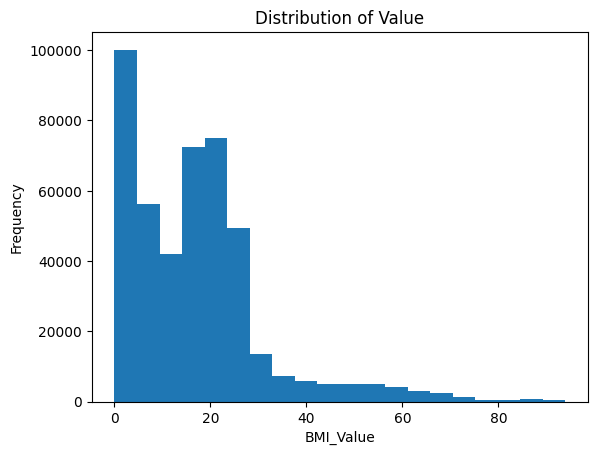

In [8]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("BMI_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


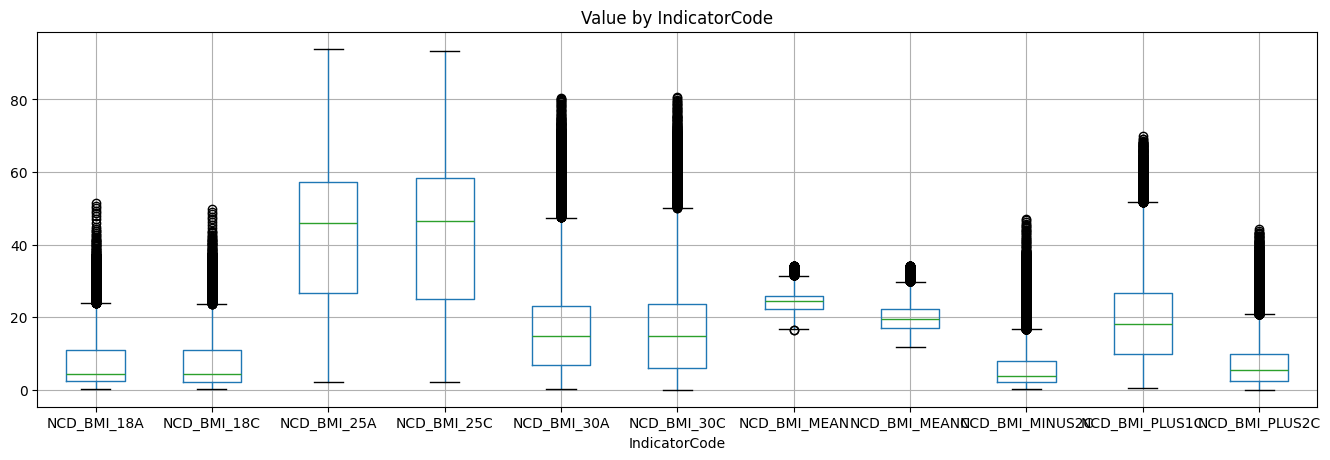

In [9]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()